# 🌀 Clifford Strange Attractor
### 6 million chaotic steps — painting with pure determinism

`Strange Attractor` · `Fractal Geometry` · `Flame Rendering` · `Chaos Theory`

---

## What Is Actually Happening?

### The Rule

Take a point (0.1, 0.1). Apply a rule. Record where it lands. Move it again. Repeat **six million times**. Add zero randomness. The rule is the Clifford attractor — defined by four constants (a, b, c, d):

```
xₙ₊₁ = sin(a · yₙ) + c · cos(a · xₙ)
yₙ₊₁ = sin(b · xₙ) + d · cos(b · yₙ)
```

The result looks hand-drawn, organic, infinitely intricate. It is none of those things. It is four numbers.

### Why Structure Emerges — The Attractor Set

The point is **trapped**. No matter where it starts, it inevitably enters a bounded region it can never escape — the **attractor set**. Within it the point never settles, never repeats exactly, never stops. It wanders forever tracing the same ghostly skeleton.

The attractor has **fractal geometry**: zoom into any tendril and it splits into finer tendrils. Its dimension is not a whole number — around 1.6, between a curve (1D) and a filled region (2D). This is the **Hausdorff dimension**.

### The Flame Fractal Rendering Technique

Instead of drawing each point as a pixel, a 2D histogram of counters is built — one per pixel. Each time the orbit visits near a pixel, that counter increments. After six million steps:

1. **Logarithmic scale** applied — so dense ridges don't wash out delicate filaments
2. **Gamma correction** applied
3. **Colour gradient** maps density to brightness

The brightest streaks are where the attractor spends most time — the bones of the ghost image. This technique is called **flame fractal rendering**.

> **Three panels below:** same equations, three different (a, b, c, d) values — three completely different attractor shapes.

---

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import animation
from IPython.display import HTML, display
import warnings; warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor':  '#03020a',
    'axes.facecolor':    '#03020a',
    'axes.edgecolor':    '#1a0a30',
    'text.color':        '#c8b8ff',
    'axes.labelcolor':   '#c8b8ff',
    'xtick.color':       '#5030a0',
    'ytick.color':       '#5030a0',
    'font.family':       'monospace',
})
print("Ready.")

Ready.


  Iterating 'Folded ribbon' ... done
  Iterating 'Branching tree' ... done
  Iterating 'Collapsed spiral' ... done


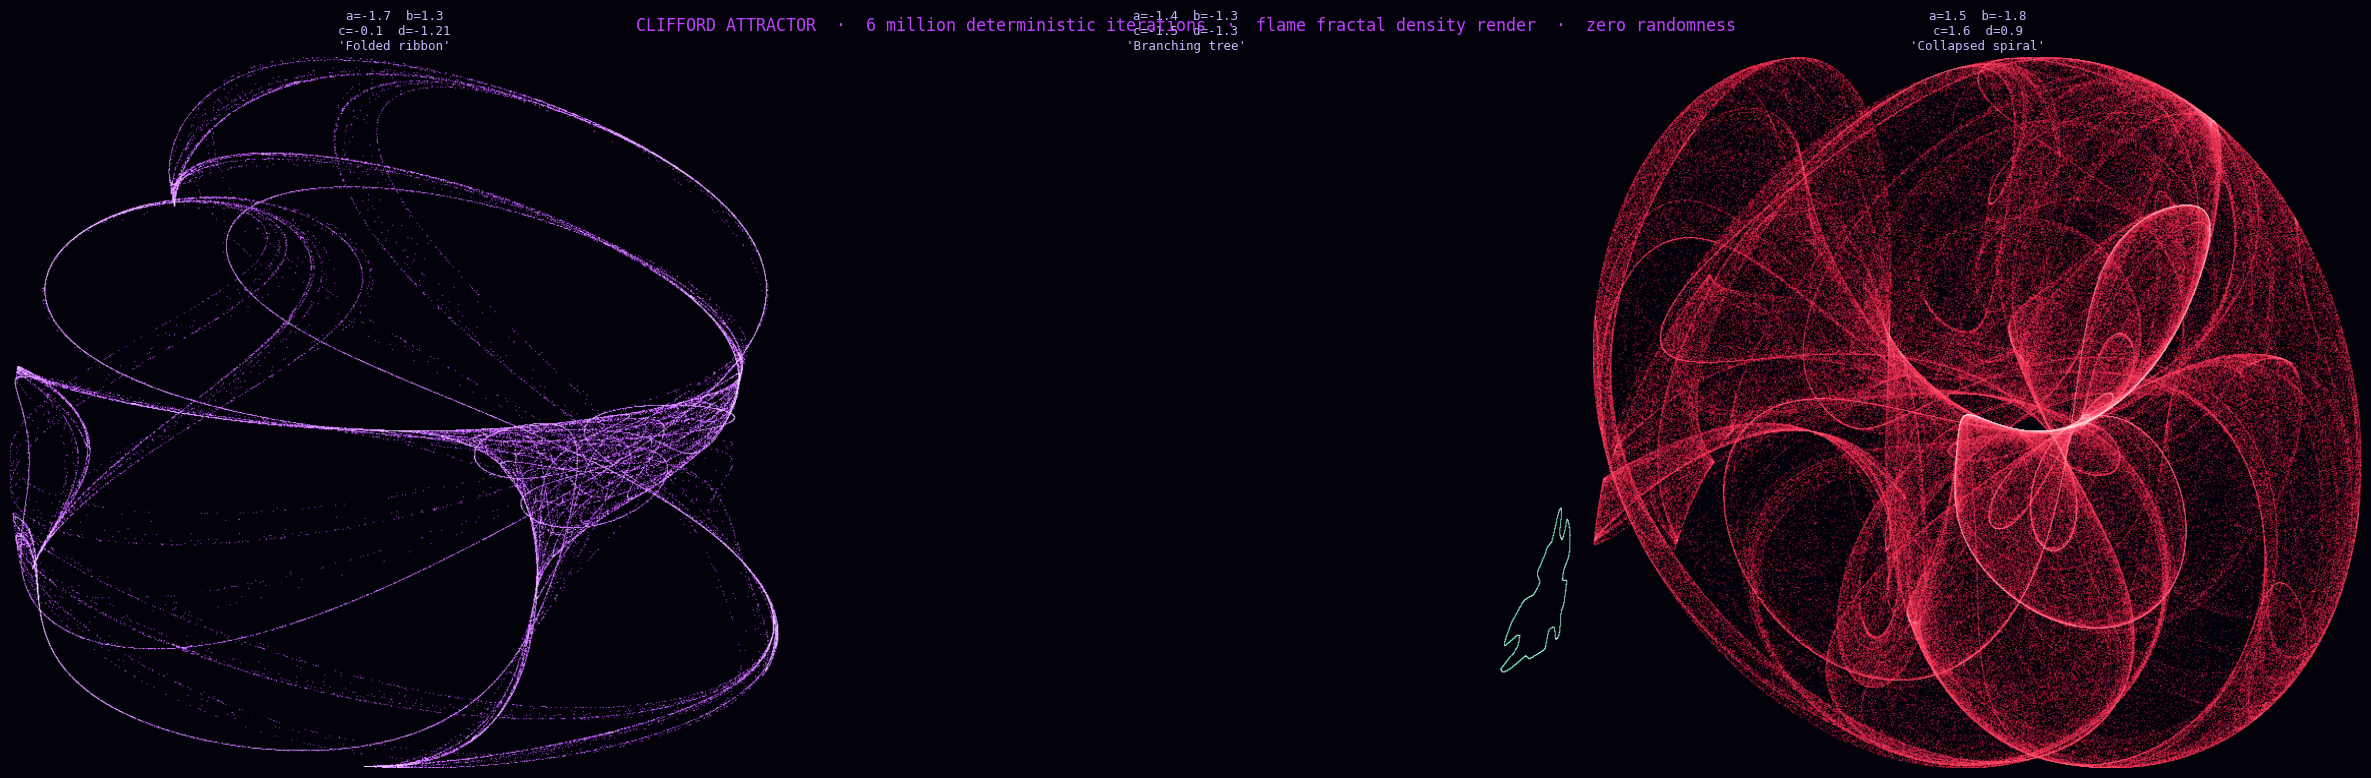

No randomness. No noise. Four numbers — infinite fractal structure.


In [8]:
def clifford_pts(a, b, c, d, n=6_000_000):
    x, y = np.float32(0.1), np.float32(0.1)
    xs, ys = np.empty(n, np.float32), np.empty(n, np.float32)
    for i in range(n):
        xs[i] = x;  ys[i] = y
        x, y = (np.sin(a*y) + c*np.cos(a*x),
                np.sin(b*x) + d*np.cos(b*y))
    return xs, ys

def hrender(xs, ys, W=1000, H=700, g=0.45):
    # Log-density histogram — flame fractal rendering
    xr = xs.max() - xs.min();  yr = ys.max() - ys.min()
    ix = np.clip(((xs-xs.min())/(xr+1e-9)*(W-1)).astype(int), 0, W-1)
    iy = np.clip(((ys-ys.min())/(yr+1e-9)*(H-1)).astype(int), 0, H-1)
    h = np.zeros((H, W), np.float32)
    np.add.at(h, (iy, ix), 1)
    h = np.log1p(h);  h /= h.max()
    return h ** g

param_sets = [
    (-1.7,  1.3, -0.1, -1.21, "a=-1.7  b=1.3\nc=-0.1  d=-1.21\n'Folded ribbon'"),
    (-1.4, -1.3, -1.5,  -1.3, "a=-1.4  b=-1.3\nc=-1.5  d=-1.3\n'Branching tree'"),
    ( 1.5, -1.8,  1.6,   0.9, "a=1.5  b=-1.8\nc=1.6  d=0.9\n'Collapsed spiral'"),
]
cmaps = [
    LinearSegmentedColormap.from_list("c1", ["#03020a","#1a0030","#6010c0","#c040ff","#fff"]),
    LinearSegmentedColormap.from_list("c2", ["#03020a","#001a10","#006040","#00f5a0","#fff"]),
    LinearSegmentedColormap.from_list("c3", ["#03020a","#200010","#800020","#ff4060","#fff"]),
]

fig, axes = plt.subplots(1, 3, figsize=(24, 8), facecolor='#03020a')
fig.subplots_adjust(left=.01, right=.99, top=.92, bottom=.03, wspace=.03)

for ax, (a,b,c,d,lb), cm in zip(axes, param_sets, cmaps):
    print(f"  Iterating {lb.split(chr(10))[2]} ...", end=" ", flush=True)
    xs, ys = clifford_pts(a, b, c, d)
    h = hrender(xs, ys)
    print("done")
    ax.imshow(h, cmap=cm, origin='lower', aspect='auto', interpolation='bilinear')
    ax.set_title(lb, color='#c8b8ff', fontsize=9, pad=5)
    ax.axis('off')

fig.suptitle("CLIFFORD ATTRACTOR  ·  6 million deterministic iterations  ·  flame fractal density render  ·  zero randomness",
             color='#c040ff', fontsize=12, y=.97)
plt.show()
print("No randomness. No noise. Four numbers — infinite fractal structure.")